In [1]:
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from scipy.optimize import curve_fit

plt.style.use('bmh')


## Divergencia y exponente en la suceptibilidad

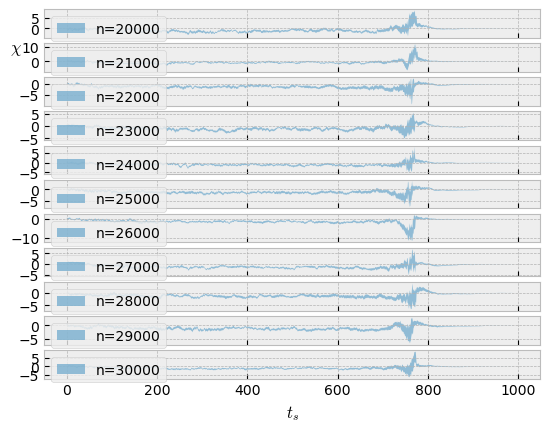

In [3]:
timesteps = 1000

h = 0.01

time_array = np.arange(timesteps)

ndata_list = np.arange(start=20000, stop=31000, step=1000)

fig, ax = plt.subplots(len(ndata_list), sharex=True)



ax[-1].set_xlabel(r'$t_s$')
ax[1].set_ylabel(r'$ \chi $', rotation='horizontal')

suceptibility_max = np.zeros((len(ndata_list)))

for i in range(len(ndata_list)):

    ndata = ndata_list[i]

    average_maximums = pd.read_csv(fr'data/AM_n={ndata}.csv', header=None).to_numpy()
    standard_error_maximums = pd.read_csv(fr'data/SE_n={ndata}.csv', header=None).to_numpy()

    suceptibility = (average_maximums[1] - average_maximums[0]) / (2*h)

    sigma = np.sqrt(standard_error_maximums[0]**2 + standard_error_maximums[1]**2) / (2 * h)

    ax[i].fill_between(time_array, y1=suceptibility+sigma, y2=suceptibility-sigma,
                    label=f'n={ndata}', alpha=0.5, lw=0)

    ax[i].legend(loc='upper left')

    suceptibility_max[i] = time_array[np.argmax(suceptibility)]

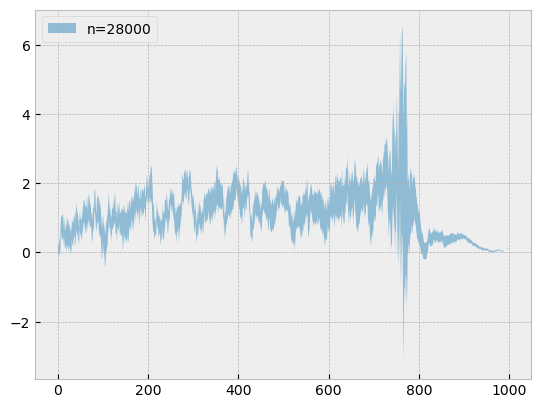

In [ ]:
fig, ax = plt.subplots()

ndata = ndata_list[-3]

average_maximums = pd.read_csv(fr'data/AM_n={ndata}.csv', header=None).to_numpy()
standard_error_maximums = pd.read_csv(fr'data/SE_n={ndata}.csv', header=None).to_numpy()

suceptibility = (average_maximums[1] - average_maximums[0]) / (2*h)

sigma = np.sqrt(standard_error_maximums[0]**2 + standard_error_maximums[1]**2) / (2 * h)


ax.fill_between(time_array, y1=suceptibility+sigma, y2=suceptibility-sigma,
                    label=f'n={ndata}', alpha=0.5, lw=0)

ax.legend(loc='upper left')

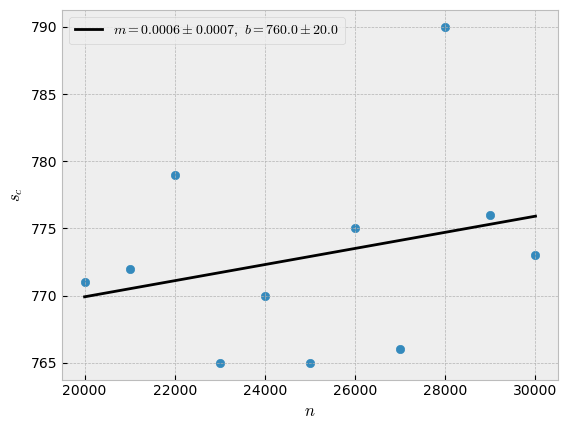

In [ ]:
x = np.array(1 / ndata_list)
y = np.array(suceptibility_max)

# Ajuste lineal con covarianza
popt, pcov = np.polyfit(x, y, 1, cov=True)

m, b = popt                      # pendiente e intercepto
dm, db = np.sqrt(np.diag(pcov))  # incertidumbres

# Función para redondear incertidumbre a 1 cifra significativa
def round_uncertainty(val, err):
    import math
    if err == 0:
        return val, err
    order = int(np.floor(np.log10(abs(err))))
    err_rounded = round(err, -order)
    val_rounded = round(val, -order)
    return val_rounded, err_rounded

m_r, dm_r = round_uncertainty(m, dm)
b_r, db_r = round_uncertainty(b, db)

# Crear figura
fig, ax = plt.subplots()

ax.set_xlabel(r'$n$')
ax.set_ylabel(r'$s_c$')

# Scatter
ax.scatter(x, y)

# Recta ajustada
xfit = np.linspace(min(x), max(x), 100)
yfit = m * xfit + b
ax.plot(xfit, yfit, label=rf'$m={m_r}\pm{dm_r},\ b={b_r}\pm{db_r}$', c='k')

ax.legend()

plt.show()

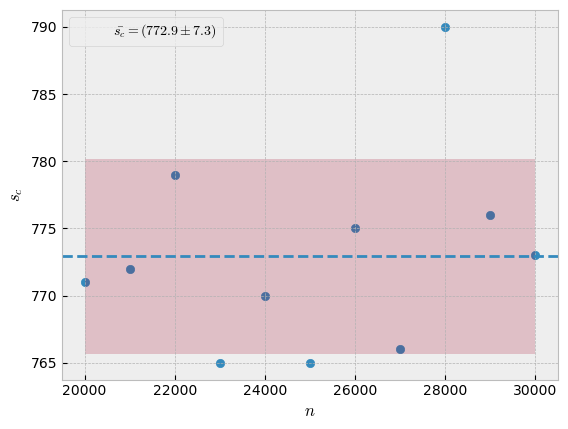

In [57]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array(ndata_list)
y = np.array(suceptibility_max)

# Promedio y desviación estándar
y_mean = np.mean(y)
y_std = np.std(y, ddof=1)  # desviación estándar muestral

# Función para notación científica con 1 cifra significativa en la incertidumbre
def sci_notation(val, err):
    import math
    if err == 0:
        return val, err, 0
    
    exponent = int(np.floor(np.log10(abs(err))))
    err_scaled = err / 10**exponent
    val_scaled = val / 10**exponent
    
    err_rounded = round(err_scaled, 1)   # 1 cifra significativa
    val_rounded = round(val_scaled, 1)
    
    return val_rounded, err_rounded, exponent

val_r, err_r, exp = sci_notation(y_mean, y_std)

# Crear figura
fig, ax = plt.subplots()

ax.set_xlabel(r'$n$')
ax.set_ylabel(r'$s_c$')

# Scatter
ax.scatter(x, y)

# Línea del promedio
ax.axhline(y_mean, linestyle='--')

# Banda de desviación estándar
ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2)

# Leyenda en notación científica
ax.plot([], [], ' ', label=rf'$\bar{{s_c}}=({val_r}\pm{err_r})$')

ax.legend()

plt.show()

## Exponente crítico 1/2

/tmp/ipykernel_44665/4011243804.py:61: RuntimeWarning: divide by zero encountered in log
  logx = np.log(reduced_time_array[tc:])[:tol]
/tmp/ipykernel_44665/4011243804.py:61: RuntimeWarning: divide by zero encountered in log
  logx = np.log(reduced_time_array[tc:])[:tol]
/tmp/ipykernel_44665/4011243804.py:61: RuntimeWarning: divide by zero encountered in log
  logx = np.log(reduced_time_array[tc:])[:tol]
/tmp/ipykernel_44665/4011243804.py:61: RuntimeWarning: divide by zero encountered in log
  logx = np.log(reduced_time_array[tc:])[:tol]
/tmp/ipykernel_44665/4011243804.py:61: RuntimeWarning: divide by zero encountered in log
  logx = np.log(reduced_time_array[tc:])[:tol]
/tmp/ipykernel_44665/4011243804.py:61: RuntimeWarning: divide by zero encountered in log
  logx = np.log(reduced_time_array[tc:])[:tol]
/tmp/ipykernel_44665/4011243804.py:61: RuntimeWarning: divide by zero encountered in log
  logx = np.log(reduced_time_array[tc:])[:tol]
/tmp/ipykernel_44665/4011243804.py:61: RuntimeWa

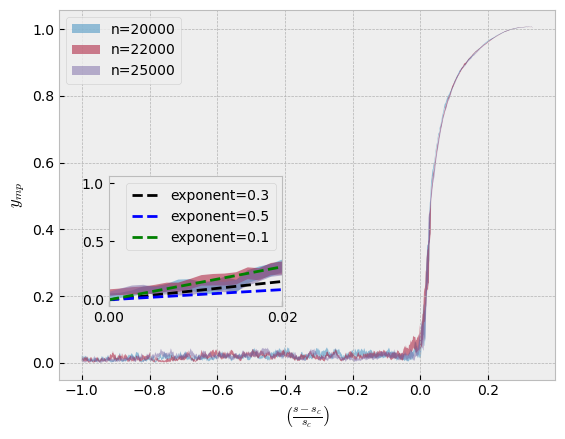

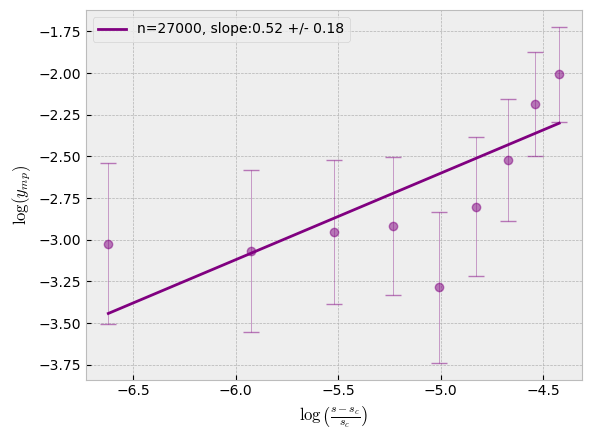

In [39]:
fig1, ax1 = plt.subplots()

x = np.linspace(0,1, 20)

axin = ax1.inset_axes([0.1,0.2, 0.35,0.35])
axin.set_xlim(0,0.02)
axin.set_xticks([0,0.02])
axin.plot(x, x**(0.3), c='k', ls='dashed', label='exponent=0.3')
axin.plot(x, x**(0.5), c='blue', ls='dashed', label='exponent=0.5')
axin.plot(x, x**(0.1), c='green', ls='dashed', label='exponent=0.1')


axin.legend()
axin.grid()

fig2, ax2 = plt.subplots()

ax1.set_xlabel(r'$\left(\frac{s-s_c}{s_c}\right)$')
ax1.set_ylabel(r'$y_{m p}$')

ax2.set_xlabel(r'$\log \left(\frac{s-s_c}{s_c}\right)$')
ax2.set_ylabel(r'$\log (y_{m p})$')


def FindSlopes(ndata_list):

    def lin_func(x, slope, intercept):
        return slope*x + intercept


    parameter_array = np.zeros((len(ndata_list),2))
    perrors = np.zeros((len(ndata_list),2))


    for i in range(len(ndata_list)):

        ndata = ndata_list[i]
        #tc = int(suceptibility_max[i])
        tc = 750
        reduced_time_array = (time_array - tc) / tc 

        

        average_maximums = pd.read_csv(fr'data/AM_n={ndata}_c=0.csv', header=None).to_numpy()
        standard_error_maximums = pd.read_csv(fr'data/SE_n={ndata}_c=0.csv', header=None).to_numpy()

        average_maximums = average_maximums[0]
        standard_error_maximums = standard_error_maximums[0]

        if i==0 or i==2 or i==5:

            ax1.fill_between(reduced_time_array, y1=average_maximums+standard_error_maximums, y2=average_maximums-standard_error_maximums,
                                label=f'n={ndata}', alpha=0.5, lw=0)
            axin.fill_between(reduced_time_array, y1=average_maximums+standard_error_maximums, y2=average_maximums-standard_error_maximums,
                                alpha=0.5, lw=0)


        tol = 10

        logy = np.log(average_maximums[tc:])[:tol]
        logx = np.log(reduced_time_array[tc:])[:tol]

        sigma_logy = standard_error_maximums[tc:] / average_maximums[tc:]
        sigma_logy = sigma_logy[:tol]
        

        ###
        mask = np.isfinite(logx) & np.isfinite(logy) & np.isfinite(sigma_logy)
        logx = logx[mask]
        logy = logy[mask]
        sigma_logy = sigma_logy[mask]
        ####

        popt, pcov = curve_fit(lin_func, logx, logy, sigma=sigma_logy)

        perr = np.sqrt(np.diag(pcov))

        if i == 7:

            label = fr'n={ndata}, slope:{round(popt[0],2)} +/- {round(perr[0],2)}'

            ax2.errorbar(logx, logy, yerr=sigma_logy, 
                         fmt='o', capsize=6, color='purple', alpha=0.5, elinewidth=0.5)
            ax2.plot(logx, popt[0]*logx + popt[1], color='purple', label=label)

        parameter_array[i] = popt
        perrors[i] = perr
    
    ax2.legend()
    ax1.legend()

    return parameter_array, perrors

parameter_array, perrors = FindSlopes(ndata_list)

fig1.savefig('ymp_exp.pdf')
fig2.savefig('ymp_regression.pdf')


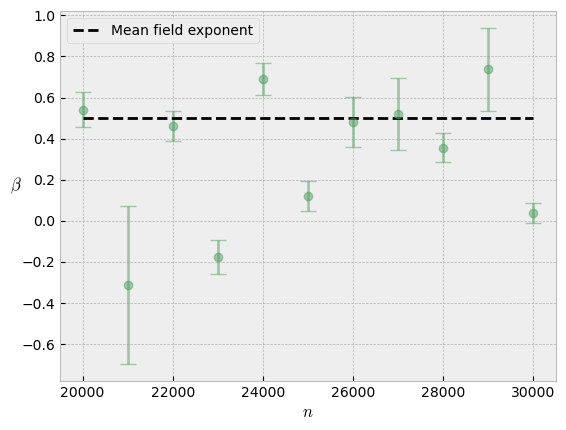

In [40]:
fig, ax = plt.subplots()

ax.set_xlabel(r'$n$')
ax.set_ylabel(r'$\beta$', rotation='horizontal')

ax.errorbar(ndata_list, parameter_array[:,0], yerr=perrors[:,0], 
            fmt='o', capsize=6, color="#51A162", alpha=0.5)
ax.hlines(y=1/2,xmin=ndata_list[0],xmax=ndata_list[-1],ls='dashed',color='k',label='Mean field exponent')

ax.legend()
fig.savefig('beta.pdf')
